# Fase 16 - Análise Exploratória dos Vídeos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Define o caminho até o dataset de vídeos.

In [ ]:
DATASET_PATH = "../data/preprocessed_shorts.csv"

In [ ]:
df = pd.read_csv(DATASET_PATH)

0    529995
1       176
2      2057
3       172
4       236
Name: viewCount, dtype: int64


# Análise de Frequência Temporal

Nesta etapa foi elaborado um gráfico da frequência temporal de vídeos ao longo do período de coleta dos dados. É possível estabelecer um padrão entre os picos de publicações com o acontecimento de fatos marcantes. 

In [20]:
def temporal_freq_chart(df):
    videos_per_day = df.resample('D', on='publishedAt').size()

    plt.figure(figsize=(12, 5))
    videos_per_day.plot(kind='line', marker='o', color='red')
    plt.title('Quantidade de videos postados por dia')
    plt.xlabel('Data')
    plt.ylabel('Videos')
    plt.grid(True)
    plt.show()

Grafico de frequencia temporal dos videos ao longo do tempo:


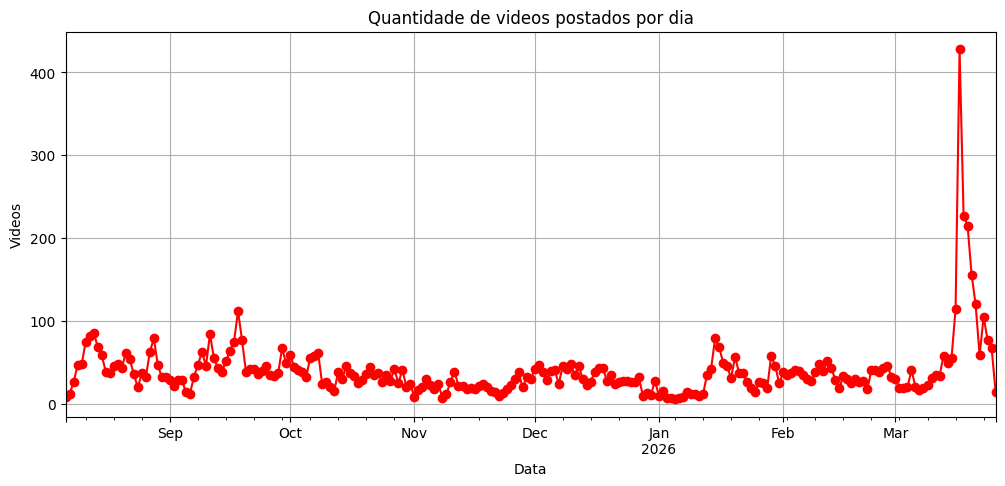

In [21]:
df['publishedAt'] = pd.to_datetime(df['publishedAt'])

print('Grafico de frequencia temporal dos videos ao longo do tempo:')
temporal_freq_chart(df)
print()

# Distribuição de views entre os vídeos

In [ ]:
def scatterplot_views_video(views_per_video):
    plt.figure(figsize=(12,6))
    plt.scatter(views_per_video.index, views_per_video['viewCount'], alpha=0.6, c='royalblue', edgecolors='w', s=50)

    plt.yscale('log')

    media = views_per_video['viewCount'].mean()
    mediana = views_per_video['viewCount'].median() 

    plt.axhline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
    plt.axhline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')

    #plt.title('Distribuição da Quantidade de Views por Vídeo', fontsize=15)
    plt.xlabel('Vídeos', fontsize=12)
    plt.ylabel('Views', fontsize=12)
    plt.legend()
    plt.grid(True, which='both', linestyle=':', alpha=0.4)

    plt.show()

[529995.0, 176.0, 2057.0, 172.0, 236.0, 16722.0, 3746.0, 521.0, 309.0, 12.0, 3679.0, 1.0, 22198.0, 23728.0, 5.0, 74234.0, 12985.0, 11927.0, 6.0, 11865.0, 63.0, 496.0, 150.0, 59.0, 4.0, 828.0, 327.0, 9146.0, 955.0, 1438.0, 920.0, 2242.0, 699.0, 640176.0, 6257.0, 174739.0, 12.0, 264774.0, 109142.0, 158403.0, 589.0, 1746.0, 1204859.0, 1127.0, 34.0, 53.0, 768.0, 1634.0, 18755.0, 2139.0, 591226.0, 465.0, 1470.0, 218498.0, 2.0, 216.0, 6015.0, 4.0, 5999.0, 9.0, 1633.0, 5170.0, 81834.0, 25341.0, 1118.0, 46.0, 9077.0, 1512.0, 55.0, 13.0, 63996.0, 894.0, 3.0, 130.0, 573.0, 698.0, 111967.0, 93.0, 546.0, 40.0, 13275.0, 12586.0, 22050.0, 713.0, 19852.0, 2.0, 416.0, 1897.0, 1183.0, 185.0, 1588.0, 42.0, 197502.0, 4838.0, 71.0, 5.0, 1618.0, 9346.0, 40625.0, 278.0, 806.0, 3011360.0, 6.0, 38.0, 121.0, 3905.0, 4558.0, 1149.0, 53.0, 14785.0, 12.0, 123.0, 960.0, 777.0, 1559.0, 87.0, 59.0, 1455869.0, 13.0, 63.0, 8770.0, 36.0, 103.0, 6090.0, 35991.0, 5.0, 1.0, 17257.0, 653.0, 26.0, 6197.0, 1.0, 50.0, 393288.

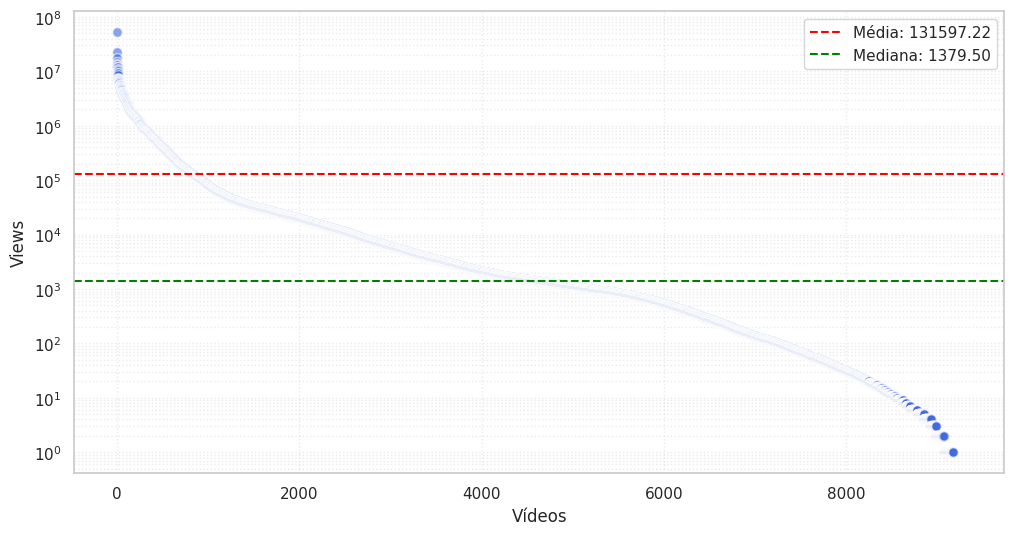

In [93]:
print(df['viewCount'].tolist())
views_per_video = df[['videoId', 'viewCount']].sort_values(by='viewCount', ascending=False).reset_index(drop=True)

print('Gráfico scatter plot da distribuição de visualizações por vídeo no dataset')
scatterplot_views_video(views_per_video)

# Gráfico de Pizza da Proporção de Vídeos Longos e de Shorts

isShorts
1    5916
0    3354
Name: count, dtype: int64


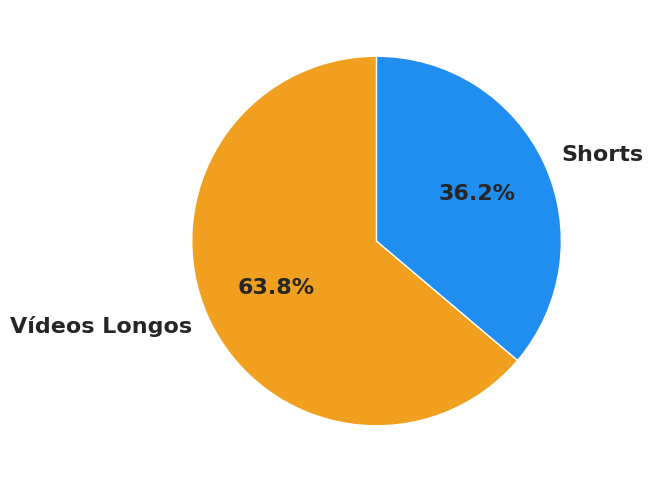

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

shorts_count = df['isShorts'].value_counts()
labels_shorts_x_longos = ['Shorts', 'Vídeos Longos'] 
plt.pie(shorts_count, labels=labels_shorts_x_longos, autopct='%1.1f%%', startangle=90, colors=['#F09F1F','#1F8EF0'], textprops={'fontsize': 16, 'weight': 'bold', 'family': 'sans-serif'})
# plt.title('Proporção de Vídeos Shorts vs Vídeos Longos')

print(shorts_count)

plt.show()

# Gráfico de Pizza da Proporção de Vídeos Marcados como Feitos para o Público Infantil

([<matplotlib.patches.Wedge at 0x71ecae13dac0>,
 [Text(-0.0499366132039408, -1.0988659311589017, 'Adultos'),
  Text(0.0499367791280796, 1.0988659236186704, 'Infantis')],
 [Text(-0.027238152656694978, -0.5993814169957645, '98.6%'),
  Text(0.02723824316077069, 0.599381412882911, '1.4%')])

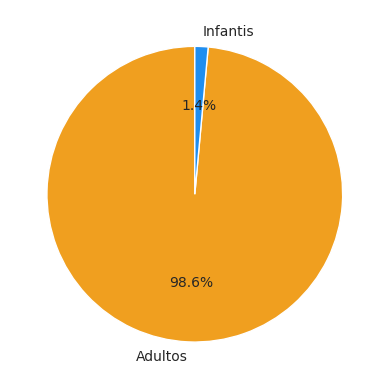

In [58]:
kids_counts = df['madeForKids'].value_counts()
labels_kids = ['Adultos', 'Infantis']
plt.pie(kids_counts, labels=labels_kids, autopct='%1.1f%%', startangle=90, colors=['#F09F1F','#1F8EF0'], textprops={'fontsize': 10, 'family': 'sans-serif'})
# plt.title('Proporção de Vídeos com Label de Feitos para Crianças')

# Núvem de Palavras das Categorias dos Vídeos, Providas pelo Próprio YouTube

In [61]:
from wordcloud import WordCloud

In [63]:
texts = df['clean_title_description'].astype(str).values
complete_text = " ".join(str(td) for td in texts)

cloud = WordCloud(
    width = 1600,
    height = 800,
    background_color = 'white',
    colormap='viridis',
    max_words=100,
    min_font_size=10
).generate(complete_text)

In [64]:
def display_cloud(cloud):
    plt.figure(figsize=(20,10), facecolor=None)
    plt.imshow(cloud, interpolation=None)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.show()

Nuvem de Palavras das Palavras-Chave dos Titulos e Descrição.


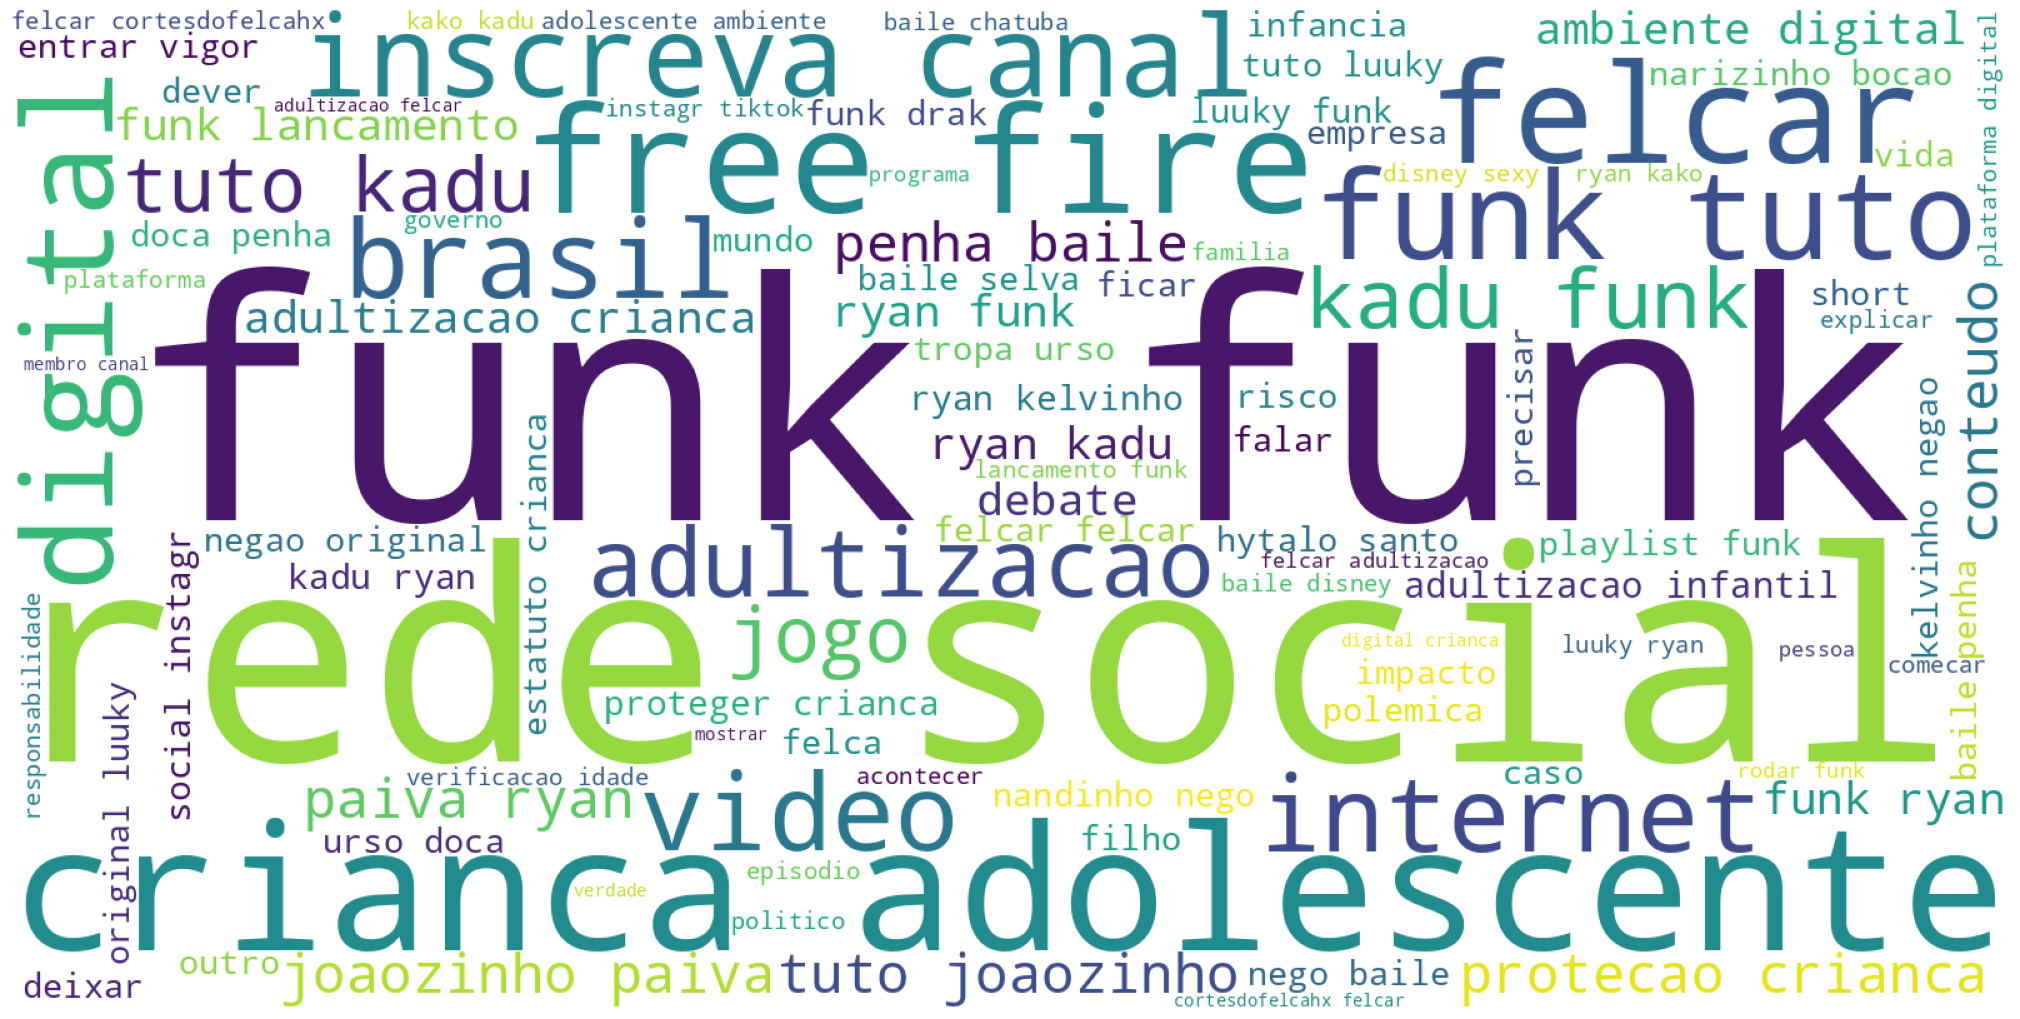

In [65]:
print("Nuvem de Palavras das Palavras-Chave dos Titulos e Descrição.")
display_cloud(cloud)
print()

# Listando os Vídeos e Canais mais Relevantes

In [67]:
df['viewCount'] = df['viewCount'].astype(float)

top_videos = df.nlargest(10, 'viewCount')[['videoId', 'title', 'channelTitle', 'viewCount']]

print("Os 10 vídeos mais vistos:")
print(top_videos)

Os 10 vídeos mais vistos:
          videoId                                              title  \
3124  FpsCzFGL1LE                                        adultização   
4019  xrBeEJ9rHms        Pegadinha BIZARRA com cabelo 🤭 IB @MrDegrEE   
1993  MjbZuUJbNOs  conheça o Cão Francisco Cisco@felquinhas   #fe...   
5844  NSYS1AV8nqE  qual a MAIOR LIGAÇÃO que dá pra fazer no whats...   
3076  A7bC-iET0kg  MINHA CACHORRA ODEIA O MC DANIEL 🦅😂 #shorts - ...   
1277  T4qpYqCw25I                                NOTAS NÃO CHOROSAXX   
7816  TDvYGZXEYF8                        ENFRENTEI O FELCA NO ROBLOX   
5204  ygV4ZWsmtIA                       eu vou fazer sua mão FLUTUAR   
387   F9mcf8yXbPE  CONFUSÃO ENTRE LUCANETA E ISAAC XAVIER #x1 #fu...   
6619  aOVNobJTfcM  LARRYZINHO FOI HUMILHADO no ROUBE O BRAINROT 😭...   

            channelTitle   viewCount  
3124               Felca  52354333.0  
4019        Brezaau blox  22552477.0  
1993       Felca Cortado  17536300.0  
5844      Giuliana Mafra 

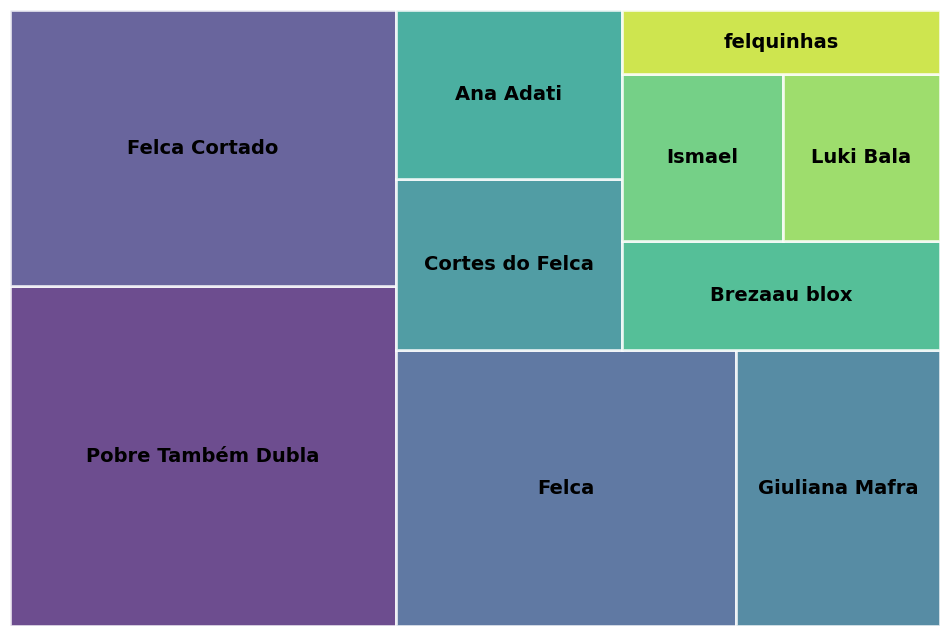

In [ ]:
import squarify 

top_canais = df.groupby('channelTitle')['viewCount'].sum().nlargest(10).reset_index()

print("Os 10 canais com mais visualizações acumuladas:")
print(top_canais)

plt.figure(figsize=(12, 8))
cores = sns.color_palette("viridis", len(top_canais))

fonte = {
    'fontsize': 14,
    'weight': 'bold',
    'color': 'black',
    'family': 'sans-serif',
}

# Treemap com os canais mais populares na base
squarify.plot(sizes=top_canais['viewCount'], 
              label=top_canais['channelTitle'], 
              alpha=0.8, 
              color=cores,
              edgecolor="white",
              linewidth=2, 
              text_kwargs=fonte)

# plt.title('Top 10 Canais por Volume de Visualizações')
plt.axis('off') 
plt.show()